In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

os.makedirs("Graphs", exist_ok=True)
airbnb_base = pd.read_csv("listings.csv", low_memory=False)

In [2]:
airbnb_base.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,57818,https://www.airbnb.com/rooms/57818,20250319035106,2025-03-21,city scrape,50% OFF Monthly 32+days! Snowbird! Walk to be...,32 + days stay ONLY with a 50% DISCOUNT. Book ...,Check-in window<br />After 3:00 PM<br />Edit<b...,https://a0.muscache.com/pictures/miso/Hosting-...,275948,...,4.97,4.88,4.70,NaN,f,2,2,0,0,0.40
1,69824,https://www.airbnb.com/rooms/69824,20250319035106,2025-03-21,city scrape,2 bd/2ba Oceanfront Condo,NaN,NaN,https://a0.muscache.com/pictures/443102/f6b94e...,351303,...,4.75,5.00,4.50,NaN,f,2,2,0,0,0.08
2,83449,https://www.airbnb.com/rooms/83449,20250319035106,2025-03-20,city scrape,2 miles from the beach 2/1 sleeps 5 #204,Mary Pop Apartments offers a 2-bedroom suite c...,"Residential neighborhood, less than 2 miles to...",https://a0.muscache.com/pictures/8c21bda0-5194...,454736,...,4.91,4.82,4.88,NaN,f,16,16,0,0,0.21
3,129099,https://www.airbnb.com/rooms/129099,20250319035106,2025-03-21,city scrape,MIAMI - AMAZING APARTMENT OCEANVIEW,Modern oceanview apartment over the beach<br /...,NaN,https://a0.muscache.com/pictures/828393/baabb6...,637272,...,4.35,4.56,4.12,NaN,f,5,5,0,0,0.17
4,191160,https://www.airbnb.com/rooms/191160,20250319035106,2025-03-19,city scrape,Tropical Beach Paradise Awaits You,Imagine being one block from the ocean in an a...,NaN,https://a0.muscache.com/pictures/1251401/83004...,924482,...,4.87,4.87,4.43,NaN,f,1,1,0,0,0.16


In [3]:
airbnb_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17238 entries, 0 to 17237
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            17238 non-null  int64  
 1   listing_url                                   17238 non-null  object 
 2   scrape_id                                     17238 non-null  int64  
 3   last_scraped                                  17238 non-null  object 
 4   source                                        17238 non-null  object 
 5   name                                          17238 non-null  object 
 6   description                                   16910 non-null  object 
 7   neighborhood_overview                         9367 non-null   object 
 8   picture_url                                   17238 non-null  object 
 9   host_id                                       17238 non-null 

In [4]:
airbnb_density = airbnb_base['calculated_host_listings_count'].sum()
print()
print("Airbnb Density:")
print(airbnb_density)


Airbnb Density:
439456


In [5]:
airbnb_base['price'] = (
    airbnb_base['price']
    .astype(str)
    .str.replace(r'[$,]', '', regex=True)
    .replace('nan', np.nan)
    .astype(float)
)

airbnb_median = airbnb_base['price'].median()


print(f"Median Airbnb Price: {airbnb_median:.2f}")


Median Airbnb Price: 200.00


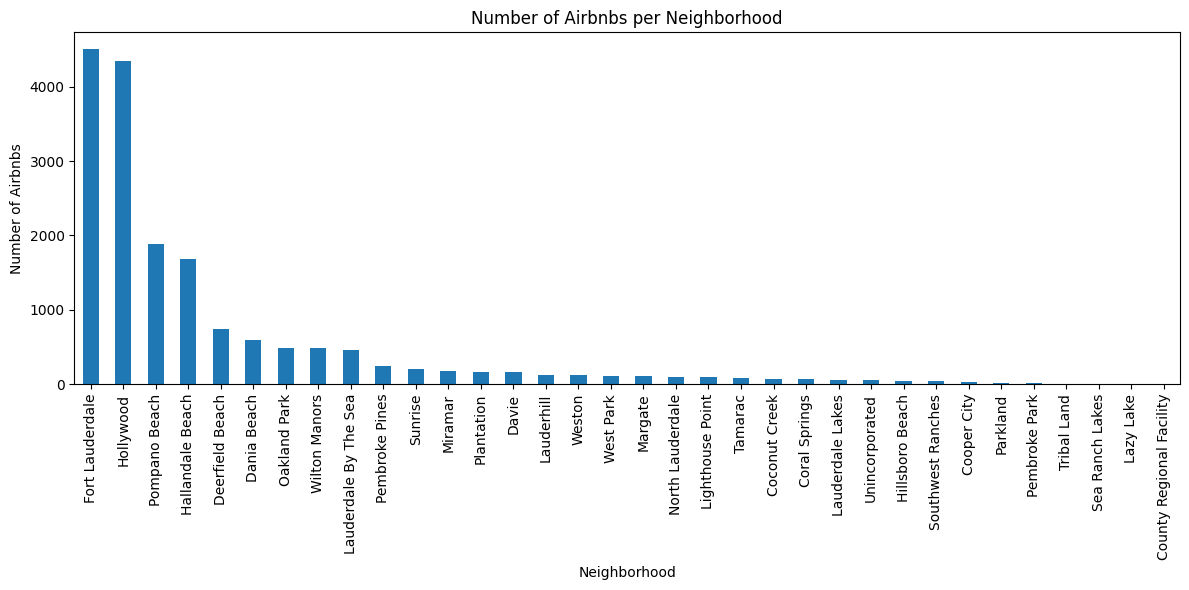

In [6]:
neighbourhood_counts = airbnb_base['neighbourhood_cleansed'].value_counts()
ax = neighbourhood_counts.plot(kind='bar', figsize=(12, 6))
ax.set_title('Number of Airbnbs per Neighborhood')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Number of Airbnbs')
plt.tight_layout()
ax.figure.savefig('Graphs/airbnbs_per_neighborhood.png', dpi=150, bbox_inches='tight')

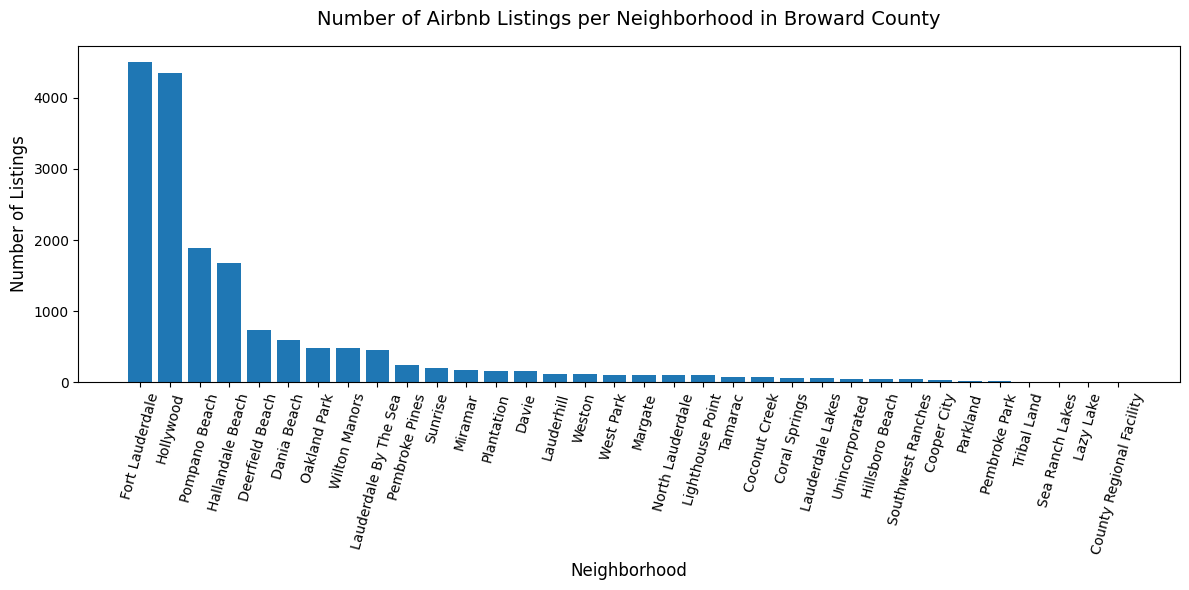

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(neighbourhood_counts.index, neighbourhood_counts.values)
ax.set_title("Number of Airbnb Listings per Neighborhood in Broward County", fontsize=14, pad=15)
ax.set_xlabel("Neighborhood", fontsize=12)
ax.set_ylabel("Number of Listings", fontsize=12)
ax.tick_params(axis='x', rotation=75)

plt.tight_layout()
fig.savefig('Graphs/listings_per_neighborhood_broward.png', dpi=150, bbox_inches='tight')
plt.show()

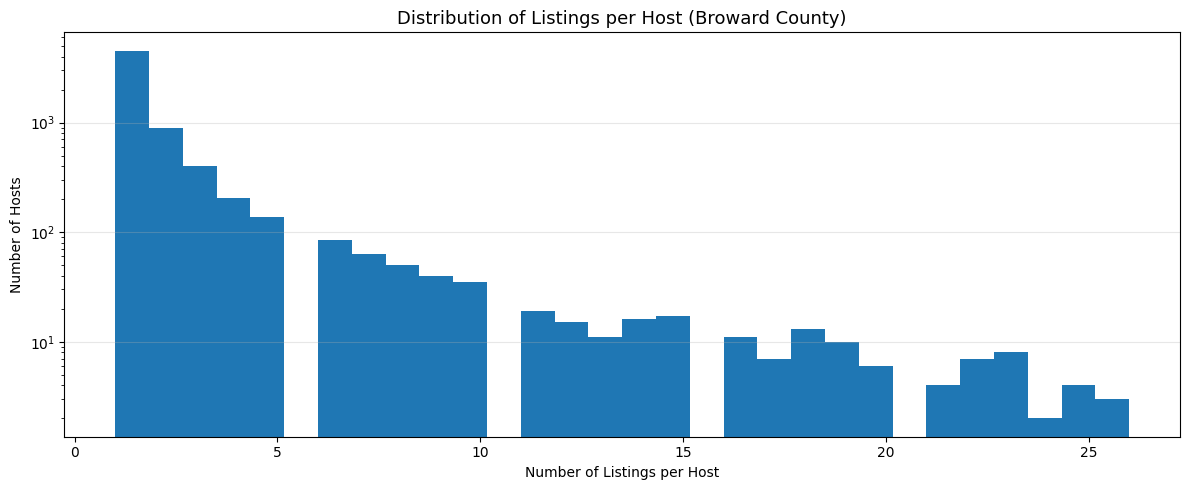

In [8]:
host_counts = airbnb_base['host_id'].value_counts()

# Remove extreme outliers (top 1%)
upper_limit = np.percentile(host_counts, 99)
filtered_counts = host_counts[host_counts <= upper_limit]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(filtered_counts, bins=30, log=True)
ax.set_title("Distribution of Listings per Host (Broward County)", fontsize=13)
ax.set_xlabel("Number of Listings per Host")
ax.set_ylabel("Number of Hosts")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig('Graphs/listings_distribution_per_host.png', dpi=150, bbox_inches='tight')
plt.show()


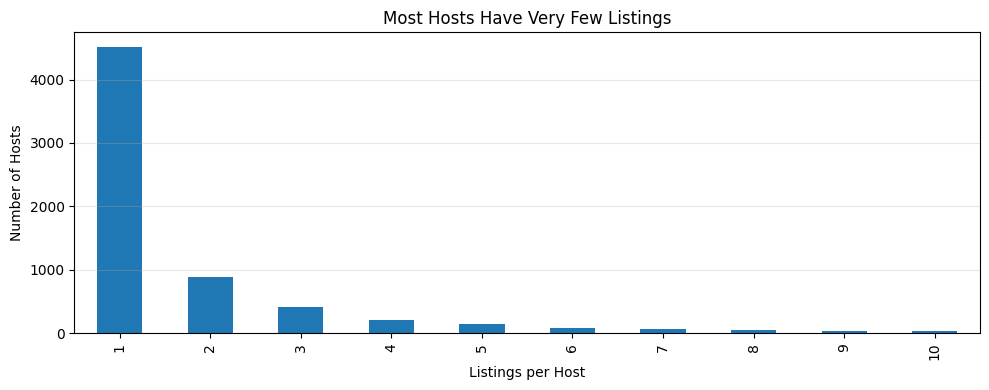

In [9]:
top_counts = host_counts.value_counts().sort_index().iloc[:10]

fig, ax = plt.subplots(figsize=(10, 4))
top_counts.plot(kind="bar", ax=ax)
ax.set_title("Most Hosts Have Very Few Listings")
ax.set_xlabel("Listings per Host")
ax.set_ylabel("Number of Hosts")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig('Graphs/top_10_listings_per_host.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Use only rows with price and cleaned neighborhood

df = airbnb_base.copy()

# Listing type: entire vs not entire
df['is_entire_home'] = df['room_type'].eq('Entire home/apt').astype(int)

# Normalize neighborhood name
df['nbhd'] = df['neighbourhood_cleansed'].fillna('Unknown').str.strip()


In [11]:
# Aggregated neighborhood metrics
nbhd_stats = (
    df.groupby('nbhd')
      .agg(
          listings=('id', 'count'),
          entire_share=('is_entire_home', 'mean'),
          median_price=('price', 'median')
      )
      .reset_index()
)

# Filter neighborhoods with very few listings (noise)
nbhd_stats = nbhd_stats[nbhd_stats['listings'] >= 10]

# Sort by number of listings
nbhd_stats = nbhd_stats.sort_values('listings', ascending=False)

nbhd_stats.head()


,nbhd,listings,entire_share,median_price
7,Fort Lauderdale,4507,0.870424,218.0
10,Hollywood,4349,0.909634,217.0
24,Pompano Beach,1888,0.856462,206.0
8,Hallandale Beach,1683,0.931075,188.0
6,Deerfield Beach,738,0.890244,209.0


C:\Users\pator\AppData\Local\Temp\ipykernel_14328\2232110981.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_nbhd['nbhd'], rotation=75, ha='right')


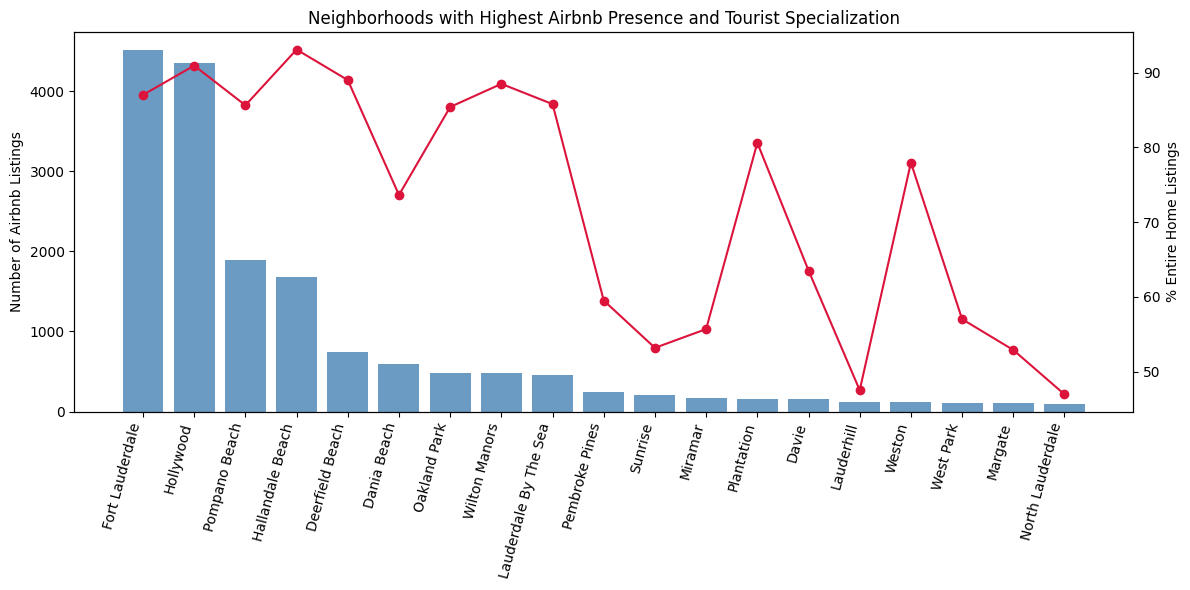

In [12]:
top_nbhd = nbhd_stats.head(19)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars: number of listings
ax1.bar(top_nbhd['nbhd'], top_nbhd['listings'], color='steelblue', alpha=0.8)
ax1.set_ylabel('Number of Airbnb Listings')
ax1.set_xticklabels(top_nbhd['nbhd'], rotation=75, ha='right')

# Line: percent entire homes
ax2 = ax1.twinx()
ax2.plot(top_nbhd['nbhd'], top_nbhd['entire_share']*100,
         color='crimson', marker='o')
ax2.set_ylabel('% Entire Home Listings')

plt.title('Neighborhoods with Highest Airbnb Presence and Tourist Specialization')
plt.tight_layout()
fig.savefig('Graphs/highest_airbnb_presence_neighborhoods.png', dpi=150, bbox_inches='tight')
plt.show()


Concentration of listings in large hosts

In [13]:
# Número de listings por host
host_counts = df.groupby('host_id')['id'].count().rename('n_listings').reset_index()

# Clasificar tamaño de host
def host_size(n):
    if n == 1:
        return '1 listing'
    elif 2 <= n <= 5:
        return '2-5 listings'
    elif 6 <= n <= 20:
        return '6-20 listings'
    else:
        return '21+ listings'

host_counts['host_size'] = host_counts['n_listings'].apply(host_size)

# Unir al dataframe
df = df.merge(host_counts, on='host_id', how='left')


Global market power distribution:

In [14]:
size_summary = (
    df.groupby('host_size')
      .agg(
          listings=('id', 'count'),
          hosts=('host_id', 'nunique')
      )
      .reset_index()
)

size_summary['share_of_listings'] = size_summary['listings'] / size_summary['listings'].sum()
size_summary['share_of_hosts'] = size_summary['hosts'] / size_summary['hosts'].sum()

size_summary


,host_size,listings,hosts,share_of_listings,share_of_hosts
0,1 listing,4520,4520,0.262211,0.679801
1,2-5 listings,4507,1638,0.261457,0.246353
2,21+ listings,4300,93,0.249449,0.013987
3,6-20 listings,3911,398,0.226882,0.059859


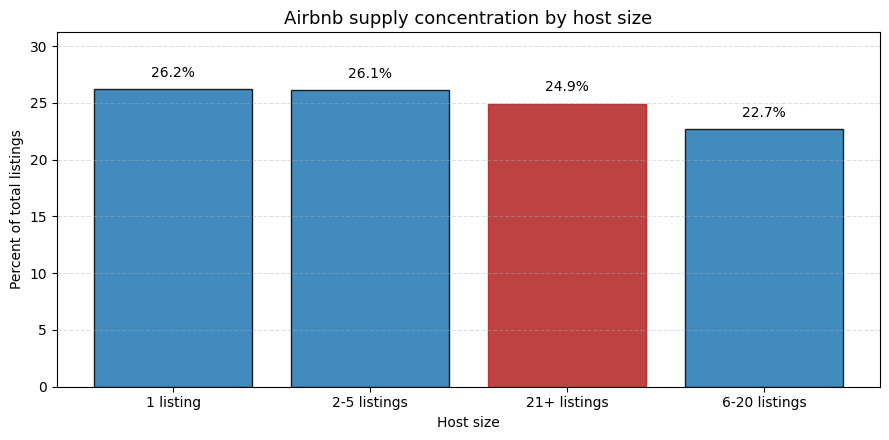

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))

values = size_summary['share_of_listings'] * 100
labels = size_summary['host_size']

bars = ax.bar(
    labels,
    values,
    edgecolor='black',
    alpha=0.85
)

# Percent labels
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.8,
        f'{v:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_ylabel('Percent of total listings')
ax.set_xlabel('Host size')
ax.set_title('Airbnb supply concentration by host size', fontsize=13)

ax.set_ylim(0, values.max() + 5)
ax.grid(axis='y', linestyle='--', alpha=0.4)

bars[-2].set_color('firebrick')

plt.tight_layout()
fig.savefig('Graphs/host_size_concentration.png', dpi=150, bbox_inches='tight')
plt.show()



Hotspots


In [16]:
# Proporción de listings que pertenecen a "grandes" hosts por barrio
df['is_big_host'] = df['n_listings'] >= 6  # puedes ajustar umbral

big_host_nbhd = (
    df.groupby('nbhd')
      .agg(
          listings=('id', 'count'),
          big_host_share=('is_big_host', 'mean'),
          entire_share=('is_entire_home', 'mean'),
          median_price=('price', 'median')
      )
      .reset_index()
)

big_host_nbhd = big_host_nbhd[big_host_nbhd['listings'] >= 10]

# Barrios top por share de grandes hosts
hotspots = big_host_nbhd.sort_values('big_host_share', ascending=False).head(15)

hotspots


,nbhd,listings,big_host_share,entire_share,median_price
8,Hallandale Beach,1683,0.684492,0.931075,188.0
10,Hollywood,4349,0.543113,0.909634,217.0
11,Lauderdale By The Sea,458,0.532751,0.858079,226.0
24,Pompano Beach,1888,0.528072,0.856462,206.0
7,Fort Lauderdale,4507,0.494786,0.870424,218.0
32,Weston,118,0.466102,0.779661,130.0
33,Wilton Manors,479,0.450939,0.885177,209.0
4,Dania Beach,588,0.411565,0.736395,140.0
6,Deerfield Beach,738,0.368564,0.890244,209.0
23,Plantation,160,0.362500,0.806250,284.5


C:\Users\pator\AppData\Local\Temp\ipykernel_14328\1369882108.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(hotspots['nbhd'], rotation=75, ha='right')


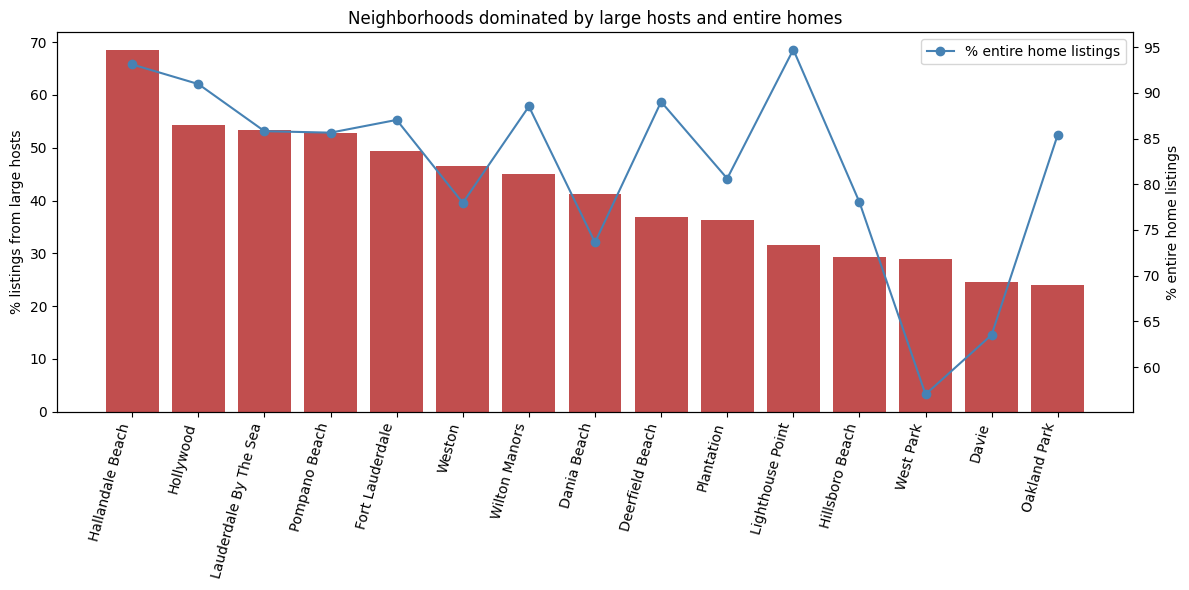

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(hotspots['nbhd'], hotspots['big_host_share']*100,
        color='firebrick', alpha=0.8, label='% listings from large hosts')
ax1.set_ylabel('% listings from large hosts')
ax1.set_xticklabels(hotspots['nbhd'], rotation=75, ha='right')

ax2 = ax1.twinx()
ax2.plot(hotspots['nbhd'], hotspots['entire_share']*100,
         color='steelblue', marker='o', label='% entire home listings')
ax2.set_ylabel('% entire home listings')

plt.title('Neighborhoods dominated by large hosts and entire homes')
plt.legend(loc='upper right')
fig.tight_layout()
fig.savefig('Graphs/large_hosts_entire_homes_hotspots.png', dpi=150, bbox_inches='tight')
plt.show()


Premium neighborhoods

In [18]:

# Price percentiles by neighborhood
price_nbhd = (
    df.groupby('nbhd')['price']
      .agg(['median', 'mean', lambda x: np.percentile(x.dropna(), 75)])
      .rename(columns={'median': 'p50', 'mean': 'mean_price', '<lambda_0>': 'p75'})
      .reset_index()
)

# Merge with Airbnb intensity
nbhd_full = nbhd_stats.merge(price_nbhd, on='nbhd', how='left')

# High-price neighborhoods with lots of listings
nbhd_full['rank_listings'] = nbhd_full['listings'].rank(ascending=False)
nbhd_full['rank_price'] = nbhd_full['p75'].rank(ascending=False)
nbhd_full['pressure_index'] = nbhd_full['rank_listings'] + nbhd_full['rank_price']

# Top neighborhoods by combined tourist pressure and price
gentrif_candidates = nbhd_full.sort_values('pressure_index').head(15)
gentrif_candidates


,nbhd,listings,entire_share,median_price,p50,mean_price,p75,rank_listings,rank_price,pressure_index
0,Fort Lauderdale,4507,0.870424,218.0,218.0,388.349559,406.00,1.0,5.0,6.0
4,Deerfield Beach,738,0.890244,209.0,209.0,279.489240,351.00,5.0,7.5,12.5
1,Hollywood,4349,0.909634,217.0,217.0,283.138711,321.00,2.0,11.0,13.0
12,Plantation,160,0.806250,284.5,284.5,404.413333,583.25,13.0,1.0,14.0
8,Lauderdale By The Sea,458,0.858079,226.0,226.0,456.275395,399.00,9.0,6.0,15.0
2,Pompano Beach,1888,0.856462,206.0,206.0,286.418491,303.25,3.0,12.0,15.0
7,Wilton Manors,479,0.885177,209.0,209.0,271.613483,351.00,8.0,7.5,15.5
3,Hallandale Beach,1683,0.931075,188.0,188.0,277.171036,289.00,4.0,14.0,18.0
6,Oakland Park,487,0.854209,198.0,198.0,226.815618,303.00,7.0,13.0,20.0
5,Dania Beach,588,0.736395,140.0,140.0,212.660517,259.50,6.0,16.0,22.0


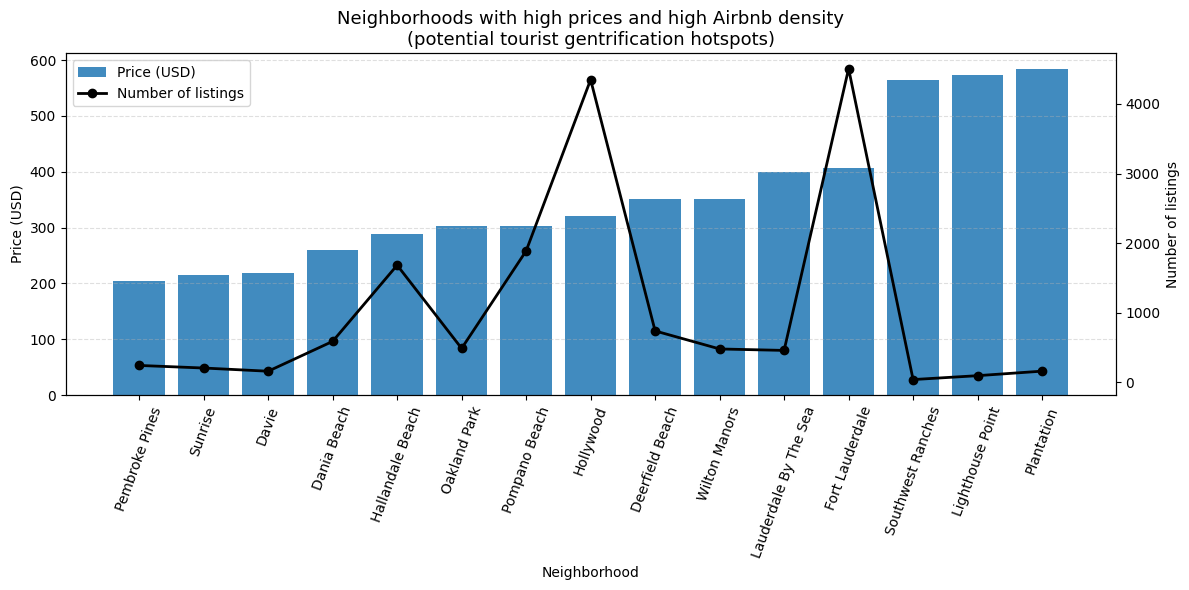

In [19]:
# Sort by p75 price (key insight)
gentrif_candidates = gentrif_candidates.sort_values('p75')

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars: high price
bars = ax1.bar(
    gentrif_candidates['nbhd'],
    gentrif_candidates['p75'],
    alpha=0.85,
    label='Price (USD)'
)

ax1.set_ylabel('Price (USD)')
ax1.set_xlabel('Neighborhood')
ax1.tick_params(axis='x', rotation=70)

# Second metric: Airbnb density
ax2 = ax1.twinx()
line = ax2.plot(
    gentrif_candidates['nbhd'],
    gentrif_candidates['listings'],
    color='black',
    marker='o',
    linewidth=2,
    label='Number of listings'
)

ax2.set_ylabel('Number of listings')

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.title(
    'Neighborhoods with high prices and high Airbnb density\n'
    '(potential tourist gentrification hotspots)',
    fontsize=13
)

plt.tight_layout()
fig.savefig('Graphs/high_price_high_density_neighborhoods.png', dpi=150, bbox_inches='tight')
plt.show()

